In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Data

In [2]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [3]:
train_data = datasets.FashionMNIST(
    root="./data_FM",
    train=True,
    transform=transform_train,
    download=True
)
test_data = datasets.FashionMNIST(
    root="./data_FM",
    train=False,
    transform=transform_test,
    download=True
)

In [4]:
train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

In [5]:
print(len(train_data), len(test_data))

60000 10000


### Models Architectures

In [6]:
model_MLP = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)
#softmax petq chi, CrossEntropyLoss um ka.

In [7]:
model_CNN = nn.Sequential(
    nn.Conv2d(1, 16, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(16, 32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(32*7*7, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

In [8]:
x = torch.randn(1, 1, 28, 28) 
output = model_CNN(x)
print(output.shape)

torch.Size([1, 10])


### Optimizers and Loss

In [9]:
loss_fn = nn.CrossEntropyLoss()
optimizer_MLP = torch.optim.Adam(model_MLP.parameters(), lr=0.001)
optimizer_CNN = torch.optim.Adam(model_CNN.parameters(), lr=0.001)

In [10]:

optimizer_MLP_SGD = optim.SGD(model_MLP.parameters(), lr=0.01, momentum=0.9)
optimizer_CNN_SGD = optim.SGD(model_CNN.parameters(), lr=0.01, momentum=0.9)

### Training the models
### with Visualizations

In [11]:
num_epochs = 5
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_MLP.to(device)
model_CNN.to(device)

train_losses_MLP, val_losses_MLP = [], []
train_accs_MLP, val_accs_MLP = [], []

train_losses_CNN, val_losses_CNN = [], []
train_accs_CNN, val_accs_CNN = [], []

def train_model(model, optimizer, train_loader, val_loader):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(num_epochs):
        #Train
        model.train()
        running_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_losses.append(running_loss/total)
        train_accs.append(correct/total)

        #Validation
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = loss_fn(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)

        val_losses.append(val_loss / total)
        val_accs.append(correct / total)
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accs[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accs[-1]:.4f}")
        
    return train_losses, val_losses, train_accs, val_accs            


In [12]:
train_losses_MLP, val_losses_MLP, train_accs_MLP, val_accs_MLP = train_model(
    model_MLP, optimizer_MLP, train_loader, test_loader)

train_losses_CNN, val_losses_CNN, train_accs_CNN, val_accs_CNN = train_model(
    model_CNN, optimizer_CNN, train_loader, test_loader)

Epoch 1/5 | Train Loss: 0.8282, Train Acc: 0.6880 | Val Loss: 0.6193, Val Acc: 0.7666
Epoch 2/5 | Train Loss: 0.6463, Train Acc: 0.7537 | Val Loss: 0.5343, Val Acc: 0.7962
Epoch 3/5 | Train Loss: 0.5945, Train Acc: 0.7745 | Val Loss: 0.5148, Val Acc: 0.8075
Epoch 4/5 | Train Loss: 0.5613, Train Acc: 0.7871 | Val Loss: 0.4890, Val Acc: 0.8205
Epoch 5/5 | Train Loss: 0.5381, Train Acc: 0.7965 | Val Loss: 0.4799, Val Acc: 0.8208
Epoch 1/5 | Train Loss: 0.7862, Train Acc: 0.7116 | Val Loss: 0.5063, Val Acc: 0.8059
Epoch 2/5 | Train Loss: 0.5336, Train Acc: 0.8016 | Val Loss: 0.4275, Val Acc: 0.8458
Epoch 3/5 | Train Loss: 0.4668, Train Acc: 0.8265 | Val Loss: 0.3777, Val Acc: 0.8611
Epoch 4/5 | Train Loss: 0.4332, Train Acc: 0.8392 | Val Loss: 0.3627, Val Acc: 0.8644
Epoch 5/5 | Train Loss: 0.4041, Train Acc: 0.8507 | Val Loss: 0.3462, Val Acc: 0.8713


In [13]:
import matplotlib.pyplot as plt
%matplotlib inline

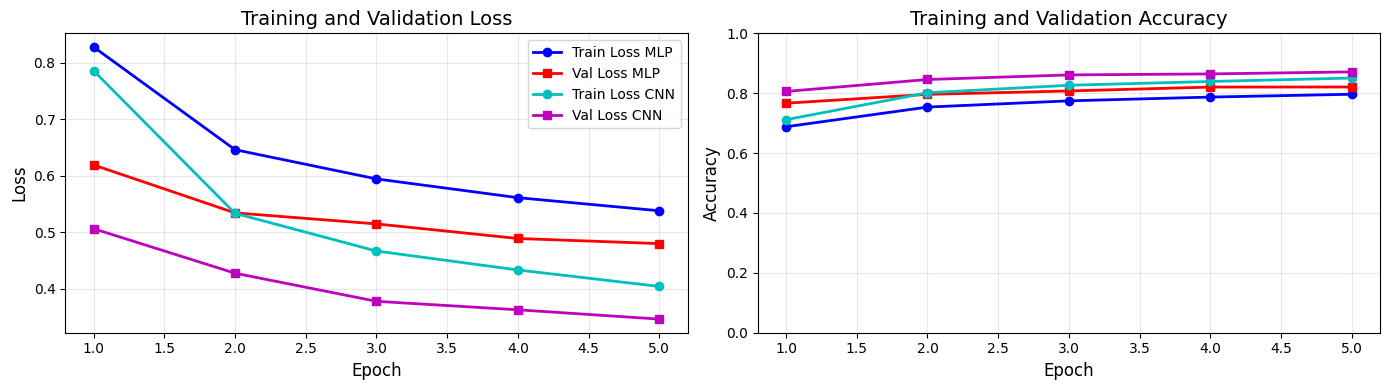

In [14]:
epochs_list = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# ----- Plot Losses -----
ax1.plot(epochs_list, train_losses_MLP, 'b-', label='Train Loss MLP', linewidth=2, marker='o')
ax1.plot(epochs_list, val_losses_MLP, 'r-', label='Val Loss MLP', linewidth=2, marker='s')
ax1.plot(epochs_list, train_losses_CNN, 'c-', label='Train Loss CNN', linewidth=2, marker='o')
ax1.plot(epochs_list, val_losses_CNN, 'm-', label='Val Loss CNN', linewidth=2, marker='s')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ----- Plot Accuracy -----
ax2.plot(epochs_list, train_accs_MLP, 'b-', label='Train Acc MLP', linewidth=2, marker='o')
ax2.plot(epochs_list, val_accs_MLP, 'r-', label='Val Acc MLP', linewidth=2, marker='s')
ax2.plot(epochs_list, train_accs_CNN, 'c-', label='Train Acc CNN', linewidth=2, marker='o')
ax2.plot(epochs_list, val_accs_CNN, 'm-', label='Val Acc CNN', linewidth=2, marker='s')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])  # accuracy from 0 to 1

plt.tight_layout()
plt.show()

In [15]:
print('MODEL PERFORMANCE with Adam')
print('='*70)

# --- MLP ---
print('MLP Model:')
print(f'Best Validation Accuracy: {max(val_accs_MLP)*100:.2f}%')
print(f'Final Validation Accuracy: {val_accs_MLP[-1]*100:.2f}%')
print(f'Final Train Loss: {train_losses_MLP[-1]:.4f}')
print(f'Final Validation Loss: {val_losses_MLP[-1]:.4f}')
print('-'*70)

# --- CNN ---
print('CNN Model:')
print(f'Best Validation Accuracy: {max(val_accs_CNN)*100:.2f}%')
print(f'Final Validation Accuracy: {val_accs_CNN[-1]*100:.2f}%')
print(f'Final Train Loss: {train_losses_CNN[-1]:.4f}')
print(f'Final Validation Loss: {val_losses_CNN[-1]:.4f}')
print('='*70)

MODEL PERFORMANCE with Adam
MLP Model:
Best Validation Accuracy: 82.08%
Final Validation Accuracy: 82.08%
Final Train Loss: 0.5381
Final Validation Loss: 0.4799
----------------------------------------------------------------------
CNN Model:
Best Validation Accuracy: 87.13%
Final Validation Accuracy: 87.13%
Final Train Loss: 0.4041
Final Validation Loss: 0.3462


### Trying change optimizer

In [16]:
train_losses_MLP, val_losses_MLP, train_accs_MLP, val_accs_MLP = train_model(
    model_MLP, optimizer_MLP_SGD, train_loader, test_loader)

train_losses_CNN, val_losses_CNN, train_accs_CNN, val_accs_CNN = train_model(
    model_CNN, optimizer_CNN_SGD, train_loader, test_loader)

Epoch 1/5 | Train Loss: 0.5116, Train Acc: 0.8078 | Val Loss: 0.4635, Val Acc: 0.8281
Epoch 2/5 | Train Loss: 0.4901, Train Acc: 0.8174 | Val Loss: 0.4371, Val Acc: 0.8424
Epoch 3/5 | Train Loss: 0.4841, Train Acc: 0.8196 | Val Loss: 0.4470, Val Acc: 0.8358
Epoch 4/5 | Train Loss: 0.4811, Train Acc: 0.8209 | Val Loss: 0.4327, Val Acc: 0.8393
Epoch 5/5 | Train Loss: 0.4686, Train Acc: 0.8254 | Val Loss: 0.4285, Val Acc: 0.8451
Epoch 1/5 | Train Loss: 0.3935, Train Acc: 0.8532 | Val Loss: 0.3304, Val Acc: 0.8832
Epoch 2/5 | Train Loss: 0.3774, Train Acc: 0.8599 | Val Loss: 0.3317, Val Acc: 0.8791
Epoch 3/5 | Train Loss: 0.3663, Train Acc: 0.8654 | Val Loss: 0.3205, Val Acc: 0.8852
Epoch 4/5 | Train Loss: 0.3545, Train Acc: 0.8684 | Val Loss: 0.3159, Val Acc: 0.8856
Epoch 5/5 | Train Loss: 0.3499, Train Acc: 0.8711 | Val Loss: 0.3160, Val Acc: 0.8845


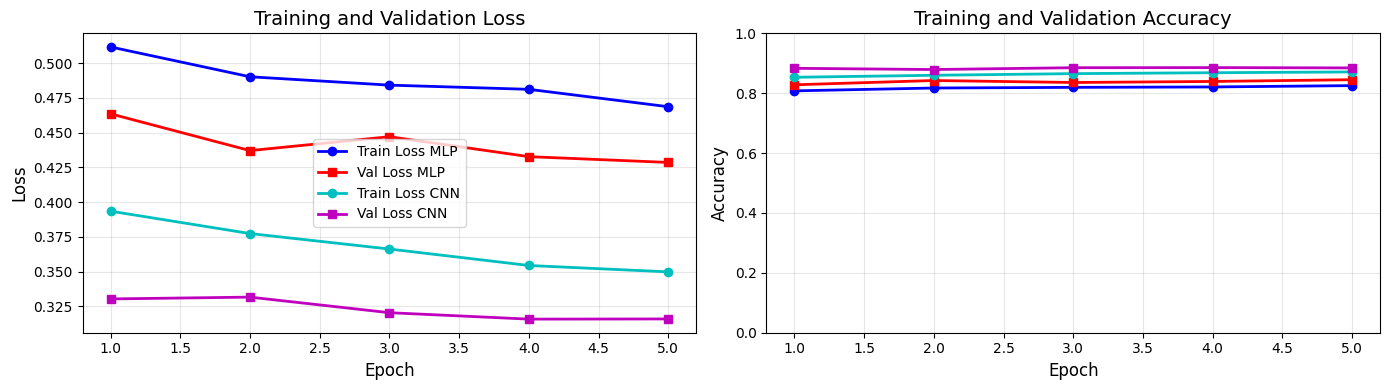

In [18]:
epochs_list = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# ----- Plot Losses -----
ax1.plot(epochs_list, train_losses_MLP, 'b-', label='Train Loss MLP', linewidth=2, marker='o')
ax1.plot(epochs_list, val_losses_MLP, 'r-', label='Val Loss MLP', linewidth=2, marker='s')
ax1.plot(epochs_list, train_losses_CNN, 'c-', label='Train Loss CNN', linewidth=2, marker='o')
ax1.plot(epochs_list, val_losses_CNN, 'm-', label='Val Loss CNN', linewidth=2, marker='s')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# ----- Plot Accuracy -----
ax2.plot(epochs_list, train_accs_MLP, 'b-', label='Train Acc MLP', linewidth=2, marker='o')
ax2.plot(epochs_list, val_accs_MLP, 'r-', label='Val Acc MLP', linewidth=2, marker='s')
ax2.plot(epochs_list, train_accs_CNN, 'c-', label='Train Acc CNN', linewidth=2, marker='o')
ax2.plot(epochs_list, val_accs_CNN, 'm-', label='Val Acc CNN', linewidth=2, marker='s')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])  # accuracy from 0 to 1

plt.tight_layout()
plt.show()

In [19]:
print('MODEL PERFORMANCE with SGD')
print('='*70)

# --- MLP ---
print('MLP Model:')
print(f'Best Validation Accuracy: {max(val_accs_MLP)*100:.2f}%')
print(f'Final Validation Accuracy: {val_accs_MLP[-1]*100:.2f}%')
print(f'Final Train Loss: {train_losses_MLP[-1]:.4f}')
print(f'Final Validation Loss: {val_losses_MLP[-1]:.4f}')
print('-'*70)

# --- CNN ---
print('CNN Model:')
print(f'Best Validation Accuracy: {max(val_accs_CNN)*100:.2f}%')
print(f'Final Validation Accuracy: {val_accs_CNN[-1]*100:.2f}%')
print(f'Final Train Loss: {train_losses_CNN[-1]:.4f}')
print(f'Final Validation Loss: {val_losses_CNN[-1]:.4f}')
print('='*70)

MODEL PERFORMANCE with SGD
MLP Model:
Best Validation Accuracy: 84.51%
Final Validation Accuracy: 84.51%
Final Train Loss: 0.4686
Final Validation Loss: 0.4285
----------------------------------------------------------------------
CNN Model:
Best Validation Accuracy: 88.56%
Final Validation Accuracy: 88.45%
Final Train Loss: 0.3499
Final Validation Loss: 0.3160
